<font size="+3"><strong>4.2. Predicting Damage with Logistic Regression</strong></font>

In [1]:
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

INTRO
We are classify into two classes based on damage, Logistic Regression is used for Classification, we are going to explain odds-ratio
Exploration - class balance, randomised train-test aplit
Model Building - Baseline - accuracy score, Iterate - Logistic Regression, Evaluation - Accuracy Score
Communication - Odds Ratio

In [2]:
def wrangle(db_path):
    # Connect to database
    conn = sqlite3.connect(db_path)

    # Construct query
    query = """
        SELECT distinct(i.building_id) AS b_id,
           s.*,
           d.damage_grade
        FROM id_map AS i
        JOIN building_structure AS s ON i.building_id = s.building_id
        JOIN building_damage AS d ON i.building_id = d.building_id
        WHERE district_id = 4
    """

    # Read query results into DataFrame
    df = pd.read_sql(query,conn, index_col="b_id")

    
    return df

In [12]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")
    
    return df

In [5]:
df = wrangle()
df.head()

,building_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,condition_post_eq,superstructure,damage_grade
0,164002,3,3,20,560,18,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Repaired and used,"Stone, mud mortar",Grade 2
1,164081,2,2,21,200,12,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Used in risk,"Stone, mud mortar",Grade 2
2,164089,3,3,18,315,20,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Used in risk,"Stone, mud mortar",Grade 2
3,164098,2,2,45,290,13,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Used in risk,"Stone, mud mortar",Grade 3
4,164103,2,2,21,230,13,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Used in risk,"Stone, mud mortar",Grade 3


In [11]:
#IDENTIFY LEAKY COLUMNS -> columns having post_eq -> post earthquake reading will be a give away for predictions
# drop_cols = []
# for col in df.columns:
#       if "post_eq" in col:
#         drop_cols.append(col)
drop_cols = [col for col in df.columns if "post_eq" in col]
drop_cols

['count_floors_post_eq', 'height_ft_post_eq', 'condition_post_eq']

In [15]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    return df

In [16]:
df = wrangle()
df.head()

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,damage_grade
b_id,,,,,,,,,,,,,
164002,3,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 2
164081,2,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 2
164089,3,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 2
164098,2,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 3
164103,2,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",Grade 3


In [17]:
print(df["damage_grade"].value_counts())

damage_grade
Grade 5    24869
Grade 4    20650
Grade 3    14097
Grade 2     7650
Grade 1     3570
Name: count, dtype: int64


In [18]:
# We'll consider Grade 5 and 4 (severely damaged) as postive class of 1 and other as 0 
#df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
#df['severe_damage'] = (df['damage_grade'] > 3).astype(int)

In [20]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    return df

In [25]:
df = wrangle()
df.head()

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,severe_damage
b_id,,,,,,,,,,,,,
164002,3,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164081,2,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164089,3,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164098,2,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164103,2,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0


In [26]:
#MULTI_COLLINEARITY
# Create correlation matrix
correlation = df.select_dtypes("number").drop(columns="severe_damage").corr()
correlation

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq
count_floors_pre_eq,1.000000,0.063214,0.198433,0.740090
age_building,0.063214,1.000000,-0.016856,0.047652
plinth_area_sq_ft,0.198433,-0.016856,1.000000,0.283496
height_ft_pre_eq,0.740090,0.047652,0.283496,1.000000


<Axes: >

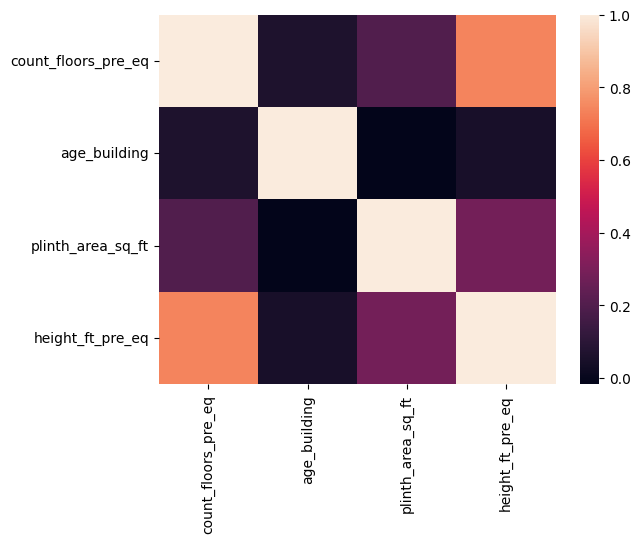

In [27]:
# Plot heatmap of `correlation`
sns.heatmap(correlation)

We can see count_floor and height of building are correlated with orange color...we need to decide which one to drop using correlation with target

In [28]:
df["severe_damage"].corr(df["count_floors_pre_eq"])

np.float64(0.002892630372575238)

In [29]:
df["severe_damage"].corr(df["height_ft_pre_eq"])

np.float64(-0.03847659083302036)

We are gonna drop first 'count_floors_pre_eq'

In [30]:
def wrangle():
    df = pd.read_csv("data/earthquake_damage.csv")

    # Rename 'building_id' to 'b_id'
    df.rename(columns={"building_id": "b_id"}, inplace=True)

    # Set 'b_id' as index
    df.set_index("b_id", inplace=True)

    # Identify and remove leaky features
    drop_cols = [col for col in df.columns if "post_eq" in col]
    df.drop(columns=drop_cols, inplace=True)

    # Binary classification of target
    df['damage_grade'] = df["damage_grade"].str[-1].astype(int)
    df['severe_damage'] = (df['damage_grade'] > 3).astype(int)
    df.drop(columns=['damage_grade'], inplace=True)

    #Multicollinearity Columns drop
    df.drop(columns=['count_floors_pre_eq'], inplace=True)


    return df

In [31]:
df = wrangle()
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,superstructure,severe_damage
b_id,,,,,,,,,,,,
164002,20,560,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164081,21,200,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164089,18,315,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164098,45,290,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
164103,21,230,13,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,"Stone, mud mortar",0
